# 1.4 Skills: Pandas 🐼

In this notebook we will cover how to:
- work with the two main data types in `pandas`: `DataFrame` and `Series`
- work with data types in `pandas`, especially strings and dates
- load data from JSON and CSV into a `DataFrame`
- manipulate the columns of a `DataFrame`
- access data in a `DataFrame` by means of indexes and slicing

In [20]:
import pandas as pd
import numpy as np

## Creating dataframes

### From scratch

We are going to create a toy dataframe with the following shape:

|    | date                |   count | event     |
|---:|:--------------------|--------:|:----------|
|  0 | 1989-05-28 00:00:00 |    7786 | fire      |
|  1 | 1985-01-10 00:00:00 |    1688 | car_crash |
|  2 | 1980-06-28 00:00:00 |    3059 | car_crash |
|  3 | 1989-03-15 00:00:00 |    6862 | flood     |
|  4 | 1986-03-05 00:00:00 |     288 | car_crash |

In [82]:
from random import randint, choice

number_records = 1000

dates = [
    pd.Timestamp(
        choice(range(1980,1990)),
        randint(1, 12),
        randint(1, 28) # try replacing with 31 and see what happens
    )
    for i in range(0, number_records)
]

In [83]:
counts = [
    randint(0, 10000)
    for i in range(0, number_records)
]

In [84]:
event_types = ["fire", "flood", "car_crash", "plane_crash"]
events = [
    np.random.choice(event_types)
    for i in range(0, number_records)
]

In [85]:
assert len(events) == len(counts) == len(dates)

In [86]:
toy_df = pd.DataFrame({
    "date": dates,
    "count": counts,
    "event": events
})

**Try out**: what happens if you change the length of either of the two lists? Try e.g. passing 20 dates instead of 10.

In [87]:
# instead of a dictionary of lists, you can pass
# a dictionary of `pandas.Series`. The result is the same.

toy_df = pd.DataFrame(
    {
        "date": pd.Series(dates),
        "count": pd.Series(counts),
        "event": pd.Series(events)
    }
)

In [88]:
toy_df

,date,count,event
0,1983-01-12,7599,flood
1,1988-11-21,9300,flood
2,1983-02-18,5954,car_crash
3,1980-04-17,3102,car_crash
4,1984-12-23,8286,fire
...,...,...,...
995,1981-06-16,3318,car_crash
996,1987-01-16,4340,flood
997,1987-09-07,6443,car_crash
998,1986-09-01,328,car_crash


In [25]:
toy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   date    1000000 non-null  datetime64[ns]
 1   count   1000000 non-null  int64         
 2   event   1000000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 22.9+ MB


In [ ]:
# a df is a collection of series
# each column is a series

type(toy_df.date)

pandas.core.series.Series

### By loading (local) data

Dataframe can be created from scratch as we did above, but most often they are created by loading existing data into a dataframe by means of `pandas`' input/oputput methods.

#### From JSON

Loading data from a JSON file is very similar to creating a `DataFrame` from a `dict`.

This is how one would do it in pure Python:

In [ ]:
import json
json_file_path = '../data/bl_books/sample/book_data_sample.json'

# JSON data gets read into a dictionary

with open(json_file_path, 'r') as jsonfile:
    json_data = json.load(jsonfile)
    
books_df = pd.DataFrame(json_data)

Since reading from files is a very common operation in any data analysis workflow, `pandas` provides methods to read from a variety of formats (JSON, CSV, clipboard, etc.)

The block of code above can be replaced by the following one-liner:

In [ ]:
books_df = pd.read_json(json_file_path)

/var/folders/dj/y_4dq5_16mb3rr89w0r1dh4c0000gr/T/ipykernel_3523/3298360895.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  books_df = pd.read_json(json_file_path)


In [ ]:
books_df.head(2)

,datefield,shelfmarks,publisher,title,edition,flickr_url_to_book_images,place,issuance,authors,date,pdf,identifier,corporate,fulltext_filename,imgs
0,1841,[British Library HMNTS 11601.ddd.2.],Privately printed,"[The Poetical Aviary, with a bird's-eye view o...",,http://www.flickr.com/photos/britishlibrary/ta...,Calcutta,monographic,{'creator': ['A. A.']},1841,{'1': 'lsidyv35c55757'},000000196,{},sample/full_texts/000000196_01_text.json,NaN
1,1888,[British Library HMNTS 9025.cc.14.],Rivingtons,[A History of Greece. Part I. From the earlies...,,http://www.flickr.com/photos/britishlibrary/ta...,London,monographic,"{'creator': ['Abbott, Evelyn']}",1888,{'1': 'lsidyv376da437'},000004047,{},sample/full_texts/000004047_01_text.json,{'0': {'000257': ['11104648374']}}


In [ ]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   datefield                  452 non-null    object
 1   shelfmarks                 452 non-null    object
 2   publisher                  452 non-null    object
 3   title                      452 non-null    object
 4   edition                    452 non-null    object
 5   flickr_url_to_book_images  452 non-null    object
 6   place                      452 non-null    object
 7   issuance                   452 non-null    object
 8   authors                    452 non-null    object
 9   date                       452 non-null    object
 10  pdf                        452 non-null    object
 11  identifier                 452 non-null    object
 12  corporate                  452 non-null    object
 13  fulltext_filename          452 non-null    object
 14  imgs      

**NB**: note the number of missing values for the `books_df.imgs` (n=172).

#### From CSV

Similarly to `pandas.read_json()`, `pandas.read_csv()` is there to make your life easier when it comes to loading CSV data into a dataframe (and that happens very often!).

Let's import one of the CSV files from the "Venice Apprenticeship" dataset (`../data/apprenticeship_venice/`).

In [28]:
csv_file_path = '../data/apprenticeship_venice/professions_data.csv'

In [29]:
garzoni_df = pd.read_csv(csv_file_path)

ParserError: Error tokenizing data. C error: Expected 7 fields in line 36, saw 8


Why it did not work??

Let's have a look at the file first...

In [ ]:
!head -n 2 ../data/apprenticeship_venice/professions_data.csv

page_title;register;annual_salary;a_profession;profession_code_strict;profession_code_gen;profession_cat;corporation;keep_profession_a;complete_profession_a;enrolmentY;enrolmentM;startY;startM;length;has_fled;m_profession;m_profession_code_strict;m_profession_code_gen;m_profession_cat;m_corporation;keep_profession_m;complete_profession_m;m_gender;m_name;m_surname;m_patronimic;m_atelier;m_coords;a_name;a_age;a_gender;a_geo_origins;a_geo_origins_std;a_coords;a_quondam;accommodation_master;personal_care_master;clothes_master;generic_expenses_master;salary_in_kind_master;pledge_goods_master;pledge_money_master;salary_master;female_guarantor;period_cat;incremental_salary
Carlo Della sosta (Orese) 1592-08-03;asv, giustizia vecchia, accordi dei garzoni, 114, 155;NA;orese;orese;orefice;orefice;Oresi;1;1;1592;08;1592;08;3;0;orese;orese;orefice;orefice;Oresi;1;1;1;Zuan Battista;Amigoni;;;0, 0;Carlo Della sosta;17;1;;;0, 0;1;0;1;1;1;0;0;0;0;0;NA;0


More than a comma-separated value, it looks like semicolon-separated values...

In [30]:
# the `sep` input parameter
# allows us to specify which character/symbol is used
# to separate column values

garzoni_df = pd.read_csv(
    csv_file_path,
    sep=';'
)

**NB**: There may be invalid lines in the data you are reading in. `read_csv()` puts you in full control of that: by setting the param `on_bad_lines` to `warn` we tell `pandas` to warn us bout bad lines and skip them (see [docs](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)). If no warning is return, then your csv is well-formed.

In [31]:
garzoni_df = pd.read_csv(
    csv_file_path,
    sep=';',
    on_bad_lines="warn",
)

<div class="alert alert-info">
    <b>More format readers</b>
    <p></p>
    Pandas supports more formats than just CSV and JSON. See the library's <a href="https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html">documentation</a> for the full list of supported formats.
</div>

### By loading (remote) data

In [26]:
textent_metadata_df = pd.read_csv('https://raw.githubusercontent.com/TextEnt/chrono-spatial-processing/refs/heads/main/data/groundtruth/textent-annotations%20-%20sample-metadata.tsv', sep='\t')

In [36]:
textent_annotations_df = pd.read_csv('https://raw.githubusercontent.com/TextEnt/chrono-spatial-processing/refs/heads/main/data/groundtruth/textent-annotations%20-%20groundtruth-annotations.tsv', sep='\t')

In [27]:
textent_metadata_df.head(2)

,document_id,author,title,annotated,exclude,keep_fine_tuning,publication_date,document_length,link,link_OCR,notes
0,bpt6k5745752g,"Boissin de Gallardon, Jean",Les tragédies et histoires saintes de Jean Boi...,False,True,False,1618,338338,http://catalogue.bnf.fr/ark:/12148/cb30122385g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
1,bpt6k5752605t,"Hauteroche, Noël Lebreton",Les bourgeoises de qualité . Comedie. Par Mr d...,True,False,False,1691,103493,http://catalogue.bnf.fr/ark:/12148/cb30582284s,https://github.com/TextEnt/chrono-spatial-proc...,NaN


In [37]:
textent_annotations_df.sample(5)

,document_id,author,title,period,period_reason,timeframe_start,timeframe_end,preferred_location,accepted_locations,location_reason,preferred_location_QID,acceptable_location_QIDs,Anthology,Unnamed: 13,Unnamed: 14
11,bpt6k1280445t,Molière,"La Critique de l'Escole des femmes, comédie pa...",Early modern,- This is a comedy - Molière is the author - P...,1600,1674,Paris,Paris | France,- Paris is mentioned - Characters have French ...,Q90,Q90 | Q142,No,NaN,NaN
28,bpt6k63412802,"Mareschal, André",Le Dictateur romain : tragédie dédiée à Mgr le...,Ancient Rome,- This is a tragedy - Historical character: Lu...,-365,-310,Rome,Rome | Roman Empire | Italy,- The palace of Camillus is mentioned as the s...,Q220,Q220 | Q2277 | Q38,No,NaN,NaN
50,bpt6k1090048g,"Puget de La Serre, Jean","Le Pyrame, tragédie en prose",Neo-Babylonian Empire,- This is a tragedy - Myth of Pyramus and Thisbe,-626,-539,Babylon,Babylon | Babylonia | Mesopotamia | Iraq,- Myth of Pyramus and Thisbe,Q5684,Q5684 | Q47690 | Q11767 | Q796,No,NaN,NaN
69,bpt6k1090242p,NaN,"Tite et Titus, ou Critique sur les Berenices, ...",Ancient Rome,- Historical character: emperor Titus Caesar V...,79,81,Mount Parnassus,Mount Parnassus | Greece,- Mount Parnassus is mentioned as the setting,Q105261,Q105261 | Q41,No,NaN,NaN
40,bpt6k9807756q,"Genest, Charles-Claude","Zelonide, princesse de Sparte . Tragedie",Ancient Greece,- This is a tragedy - Historical event: Siege ...,-272,-272,Sparta,Sparta | Greece,- Sparta is mentioned as the setting - Charact...,Q5690,Q5690 | Q41,No,NaN,NaN


## Exploring a dataframe

In [33]:
toy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   date    1000000 non-null  datetime64[ns]
 1   count   1000000 non-null  int64         
 2   event   1000000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 22.9+ MB


In [32]:
garzoni_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9653 entries, 0 to 9652
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   page_title                9653 non-null   object 
 1   register                  9653 non-null   object 
 2   annual_salary             7870 non-null   float64
 3   a_profession              9653 non-null   object 
 4   profession_code_strict    9618 non-null   object 
 5   profession_code_gen       9614 non-null   object 
 6   profession_cat            9597 non-null   object 
 7   corporation               9350 non-null   object 
 8   keep_profession_a         9653 non-null   int64  
 9   complete_profession_a     9653 non-null   int64  
 10  enrolmentY                9628 non-null   float64
 11  enrolmentM                9631 non-null   float64
 12  startY                    9533 non-null   float64
 13  startM                    9539 non-null   float64
 14  length  

In [34]:
textent_metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   document_id       70 non-null     object 
 1   author            65 non-null     object 
 2   title             70 non-null     object 
 3   annotated         70 non-null     bool   
 4   exclude           70 non-null     bool   
 5   keep_fine_tuning  70 non-null     bool   
 6   publication_date  70 non-null     int64  
 7   document_length   70 non-null     int64  
 8   link              60 non-null     object 
 9   link_OCR          70 non-null     object 
 10  notes             0 non-null      float64
dtypes: bool(3), float64(1), int64(2), object(5)
memory usage: 4.7+ KB


## Summary statistics

In [118]:
toy_df['count'].describe()

count    1000.000000
mean     4918.917000
std      2941.705442
min        18.000000
25%      2356.000000
50%      4772.500000
75%      7612.000000
max      9999.000000
Name: count, dtype: float64

In [119]:
textent_metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   document_id       70 non-null     object 
 1   author            65 non-null     object 
 2   title             70 non-null     object 
 3   annotated         70 non-null     bool   
 4   exclude           70 non-null     bool   
 5   keep_fine_tuning  70 non-null     bool   
 6   publication_date  70 non-null     int64  
 7   document_length   70 non-null     int64  
 8   link              60 non-null     object 
 9   link_OCR          70 non-null     object 
 10  notes             0 non-null      float64
dtypes: bool(3), float64(1), int64(2), object(5)
memory usage: 4.7+ KB


In [124]:
# textent_metadata_df.describe(include='all')
textent_metadata_df.describe()

,publication_date,document_length,notes
count,70.000000,70.000000,0.0
mean,1657.842857,89746.842857,NaN
std,22.545050,72756.409720,NaN
min,1604.000000,11922.000000,NaN
25%,1639.250000,57541.500000,NaN
50%,1662.000000,82399.500000,NaN
75%,1672.750000,100456.500000,NaN
max,1696.000000,541424.000000,NaN


In [125]:
textent_metadata_df['document_length'].describe()

count        70.000000
mean      89746.842857
std       72756.409720
min       11922.000000
25%       57541.500000
50%       82399.500000
75%      100456.500000
max      541424.000000
Name: document_length, dtype: float64

## Selecting columns

In [131]:
toy_df

,date,count,event,year
0,1983-01-12,7599,flood,1983
1,1988-11-21,9300,flood,1988
2,1983-02-18,5954,car_crash,1983
3,1980-04-17,3102,car_crash,1980
4,1984-12-23,8286,fire,1984
...,...,...,...,...
995,1981-06-16,3318,car_crash,1981
996,1987-01-16,4340,flood,1987
997,1987-09-07,6443,car_crash,1987
998,1986-09-01,328,car_crash,1986


In [127]:
toy_df['event']

0          flood
1          flood
2      car_crash
3      car_crash
4           fire
         ...    
995    car_crash
996        flood
997    car_crash
998    car_crash
999    car_crash
Name: event, Length: 1000, dtype: object

In [143]:
# column selection is an indirect way of dropping columns from a dataframe
toy_df[['event', 'count']]

,event,count
0,flood,7599
1,flood,9300
2,car_crash,5954
3,car_crash,3102
4,fire,8286
...,...,...
995,car_crash,3318
996,flood,4340
997,car_crash,6443
998,car_crash,328


In [144]:
# column selection can be used also to reorder columns
toy_df[['count', 'event', 'date']]

,count,event,date
0,7599,flood,1983-01-12
1,9300,flood,1988-11-21
2,5954,car_crash,1983-02-18
3,3102,car_crash,1980-04-17
4,8286,fire,1984-12-23
...,...,...,...
995,3318,car_crash,1981-06-16
996,4340,flood,1987-01-16
997,6443,car_crash,1987-09-07
998,328,car_crash,1986-09-01


## Filtering columns

In [ ]:
toy_df[toy_df['count'] < 100]

,date,count,event,year
19,1986-07-09,95,car_crash,1986
161,1983-05-12,93,fire,1983
254,1980-05-01,88,car_crash,1980
276,1982-06-04,50,plane_crash,1982
349,1988-05-21,98,plane_crash,1988
556,1988-12-10,67,car_crash,1988
715,1986-08-05,18,plane_crash,1986
723,1988-02-05,89,fire,1988
924,1984-07-14,85,flood,1984
948,1984-02-25,53,flood,1984


In [ ]:
toy_df[toy_df['count'] < 50]

,date,count,event,year
715,1986-08-05,18,plane_crash,1986


In [109]:
# how many events are there in total?
int(toy_df['count'].sum())

4918917

In [110]:
# how many events are there in 1982?
int(toy_df[toy_df['year']==1982]['count'].sum())

554182

In [113]:
toy_df[toy_df.event == 'fire']['count'].sum()

np.int64(1169068)

## Counting values

In [89]:
# count number of events by type
toy_df.event.value_counts()

event
plane_crash    290
car_crash      254
fire           233
flood          223
Name: count, dtype: int64

In [156]:
toy_df['year'] = toy_df.date.dt.year

In [157]:
# count number of events by year
toy_df.date.dt.year.value_counts()

date
1986    115
1987    111
1981    106
1982    105
1980    102
1983    102
1989     93
1984     93
1985     88
1988     85
Name: count, dtype: int64

In [160]:
# yes, head and tail methods work on series too
# here we keep only the top-5 years with the most events 
toy_df.date.dt.year.value_counts().head(5)

date
1986    115
1987    111
1981    106
1982    105
1980    102
Name: count, dtype: int64

In [142]:
toy_df.event.value_counts().to_frame().sort_values('count', ascending=False)

,count
event,
plane_crash,290
car_crash,254
fire,233
flood,223


## Plotting

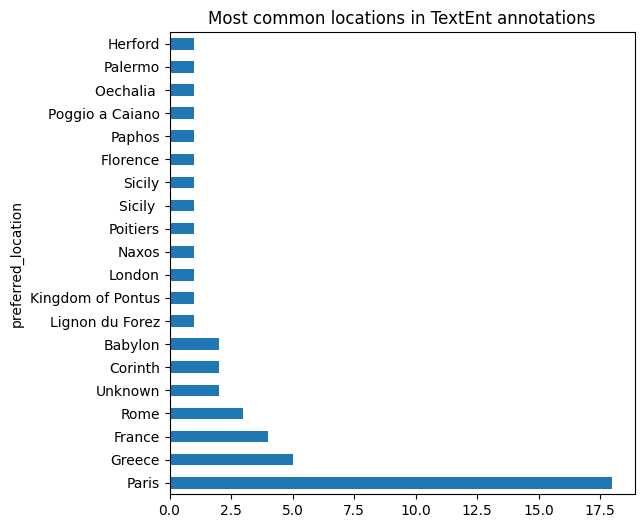

In [151]:
ax = textent_annotations_df.preferred_location.value_counts()[:20].plot(kind='barh', figsize=(6, 6), title='Most common locations in TextEnt annotations')

In [ ]:
ax.figure.savefig('../data/textent_plot.pdf')

In [155]:
ax.figure.savefig('../data/textent_plot.png')

## Indexes and merging

In [150]:
textent_metadata_df.author.is_unique

False

In [147]:
textent_metadata_df.document_id.is_unique

True

In [146]:
textent_metadata_df.set_index('document_id', inplace=False)

,author,title,annotated,exclude,keep_fine_tuning,publication_date,document_length,link,link_OCR,notes
document_id,,,,,,,,,,
bpt6k5745752g,"Boissin de Gallardon, Jean",Les tragédies et histoires saintes de Jean Boi...,False,True,False,1618,338338,http://catalogue.bnf.fr/ark:/12148/cb30122385g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k5752605t,"Hauteroche, Noël Lebreton",Les bourgeoises de qualité . Comedie. Par Mr d...,True,False,False,1691,103493,http://catalogue.bnf.fr/ark:/12148/cb30582284s,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k852919x,NaN,Le Mariage de Fine-Epice. Comédie,True,False,False,1664,134035,http://catalogue.bnf.fr/ark:/12148/cb39325270g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k12804007,Molière,"Sganarelle ou le Cocu imaginaire, comédie avec...",True,False,False,1662,67710,http://catalogue.bnf.fr/ark:/12148/cb38650865b,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k5772310n,"Corneille, Thomas","Ariane , tragédie. Par T. Corneille",True,False,False,1672,76240,http://catalogue.bnf.fr/ark:/12148/cb30272162g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
...,...,...,...,...,...,...,...,...,...,...
bpt6k62514727,"Villiers, Claude Deschamps",Les ramonneurs. Comédie . Comédie. Par Mr de V...,True,False,False,1662,63178,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k12804415,Molière,"La Critique de l'Escole des femmes, comedie. P...",True,False,False,1663,49436,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k8528543,"La Motte, de.","Le Grand Magus, Tragi-Comédie",True,False,False,1656,92787,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN


In [162]:
textent_metadata_df.set_index('document_id', inplace=True)

In [164]:
textent_annotations_df.set_index('document_id', inplace=True)

In [175]:
textent_annotations_df[['period', 'preferred_location']].merge(
    textent_metadata_df[['author', 'title']],
    left_index=True,
    right_index=True,
    how='inner'
)

,period,preferred_location,author,title
document_id,,,,
bpt6k5745752g,NaN,NaN,"Boissin de Gallardon, Jean",Les tragédies et histoires saintes de Jean Boi...
bpt6k5752605t,Early modern,Paris,"Hauteroche, Noël Lebreton",Les bourgeoises de qualité . Comedie. Par Mr d...
bpt6k852919x,Early modern,Poitiers,NaN,Le Mariage de Fine-Epice. Comédie
bpt6k12804007,Early modern,Paris,Molière,"Sganarelle ou le Cocu imaginaire, comédie avec..."
bpt6k5772310n,Ancient Greece,Naxos,"Corneille, Thomas","Ariane , tragédie. Par T. Corneille"
...,...,...,...,...
bpt6k62514727,Early modern,Paris,"Villiers, Claude Deschamps",Les ramonneurs. Comédie . Comédie. Par Mr de V...
bpt6k12804415,Early modern,Paris,Molière,"La Critique de l'Escole des femmes, comedie. P..."
bpt6k8528543,Early modern,Paris,"La Motte, de.","Le Grand Magus, Tragi-Comédie"


## `pandas`' data structures

### `Series`

In `pandas`, series are the building blocks of dataframes.

Think of a series as a column in a table. A series collects *observations* about a given *variable*. 

In [1]:
from random import random
import pandas as pd
import numpy as np

#### Numerical series

In [2]:
# let's create a series containing 100 random numbers
# ranging between 0 and 1

s = pd.Series([random() for n in range(0, 100)])

Each observation in the series has an **index** as well as a set of **values**: they can be accessed via the omonymous properties:

In [3]:
s.index

RangeIndex(start=0, stop=100, step=1)

In [4]:
list(s.index)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99]

In [5]:
s.values

array([7.38772563e-01, 6.81324592e-01, 5.46651828e-01, 7.43914780e-01,
       8.35017803e-01, 1.22741267e-01, 2.78982721e-01, 2.63898307e-01,
       9.45239902e-01, 9.89118472e-01, 1.67208520e-01, 5.61735140e-01,
       8.42224912e-01, 3.48099493e-01, 4.68860715e-02, 1.24788492e-01,
       8.83405255e-02, 6.14920020e-02, 4.52555675e-01, 7.43274354e-01,
       4.31264192e-01, 2.97959150e-01, 5.90137867e-01, 3.73853082e-01,
       9.68593542e-01, 4.67017508e-01, 4.31516791e-01, 6.16259779e-01,
       2.52304550e-01, 4.12742083e-02, 6.07152375e-01, 2.10337735e-01,
       6.67350945e-01, 1.06982486e-01, 3.27432650e-01, 8.51657096e-01,
       7.87916312e-01, 2.10008627e-01, 6.51954245e-01, 2.25906768e-01,
       7.49180861e-01, 4.39208896e-01, 4.48078902e-01, 4.62624830e-01,
       3.85784455e-01, 2.13011433e-01, 8.15812946e-01, 8.30386732e-01,
       8.93940602e-01, 9.21835682e-02, 7.79706634e-01, 5.22636637e-01,
       1.60412952e-04, 3.76677044e-01, 8.35046273e-01, 4.57511267e-01,
      

The `head()` and `tail()` methods allows for looking at the begininning and end of a series:

In [6]:
s.head()

0    0.738773
1    0.681325
2    0.546652
3    0.743915
4    0.835018
dtype: float64

In [7]:
s.tail()

95    0.244756
96    0.816011
97    0.543873
98    0.692806
99    0.533838
dtype: float64

The `value_counts()` method returns a count of distinct values within a series.

In [8]:
s.value_counts()

0.738773    1
0.448279    1
0.807995    1
0.822508    1
0.850336    1
           ..
0.607152    1
0.041274    1
0.252305    1
0.616260    1
0.533838    1
Length: 100, dtype: int64

Is there any number in `s` that occurs twice?

In [75]:
# a `Series` can be easily cast into a list

list(s.value_counts()).count(1)

100

Another way of verifying this:

In [77]:
s.is_unique

True

In [78]:
s.min()

0.03505657992551481

In [79]:
s.max()

0.9927444641218586

In [80]:
s.mean()

0.498802863531209

In [81]:
s.median()

0.5035268320708364

#### Datetime series

In [94]:
from random import randint

In [122]:
# let's generate a list of random dates
# in the range 1900-1950

dates = [
    pd.Timestamp(
        year,
        randint(1, 12),
        randint(1, 28) # try replacing with 31 and see what happens
    )
    for year in range(1900,1950)
]

In [123]:
s1 = pd.Series(dates)

In [124]:
s1

0    1900-09-01
1    1901-10-08
2    1902-04-14
3    1903-01-03
4    1904-06-09
5    1905-05-22
6    1906-07-27
7    1907-09-18
8    1908-03-03
9    1909-12-01
10   1910-06-03
11   1911-12-01
12   1912-10-04
13   1913-11-16
14   1914-08-16
15   1915-01-18
16   1916-11-23
17   1917-04-21
18   1918-12-20
19   1919-09-12
20   1920-09-16
21   1921-11-27
22   1922-12-02
23   1923-08-02
24   1924-06-15
25   1925-02-16
26   1926-03-01
27   1927-02-20
28   1928-05-17
29   1929-12-06
30   1930-03-25
31   1931-02-06
32   1932-12-08
33   1933-11-22
34   1934-04-17
35   1935-05-03
36   1936-01-19
37   1937-10-21
38   1938-04-13
39   1939-05-14
40   1940-11-21
41   1941-07-15
42   1942-07-06
43   1943-12-11
44   1944-03-07
45   1945-09-22
46   1946-04-09
47   1947-04-24
48   1948-05-19
49   1949-07-08
dtype: datetime64[ns]

In [125]:
type(s1[1])

pandas._libs.tslibs.timestamps.Timestamp

In [127]:
s1[1].day_name()

'Tuesday'

In [119]:
s1.min()

datetime.date(1900, 5, 12)

In [120]:
s1.max()

datetime.date(1949, 5, 19)

In [128]:
s1.mean()

Timestamp('1925-01-09 12:28:48')

### `DataFrame`


What is a `pandas.DataFrame`? Think of it as an in-memory spreadsheet that you can analyse and manipulate programmatically.

A `DataFrame` is a collection of `Series` having the same length and whose indexes are in sync. A *collection* means that each column of a dataframe is a series

Let's create a toy `DataFrame` by hand. 

## Data manipulation in `pandas`

### Data types

String, datetimes (see above), categorical data.

In `pandas`, categories behave very much like string, yet they lead to better performances (faster operations, optimized storage).

Bottom-up approach:

In [55]:
# transforms a Series with strings into categories
# similar to R factors

toy_df.event.astype('category')

0         plane_crash
1         plane_crash
2           car_crash
3           car_crash
4           car_crash
             ...     
999995      car_crash
999996      car_crash
999997           fire
999998    plane_crash
999999    plane_crash
Name: event, Length: 1000000, dtype: category
Categories (4, object): ['car_crash', 'fire', 'flood', 'plane_crash']

Top-down approach:

In [57]:
# here the list of categories is defined beforehand

from pandas.api.types import CategoricalDtype

cat_type = CategoricalDtype(
    categories=["flood", "fire", "car_crash", "earth_quake", "plane_crash"],
    ordered=True
)

toy_df.event = toy_df.event.astype(cat_type)

In [58]:
toy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   date    1000000 non-null  datetime64[ns]
 1   count   1000000 non-null  int64         
 2   event   1000000 non-null  category      
dtypes: category(1), datetime64[ns](1), int64(1)
memory usage: 16.2 MB


In [59]:
toy_df

,date,count,event
0,1985-11-23,3323,plane_crash
1,1985-06-17,6882,plane_crash
2,1986-09-12,9224,car_crash
3,1984-03-26,7977,car_crash
4,1980-02-08,1435,car_crash
...,...,...,...
999995,1980-05-07,2901,car_crash
999996,1987-10-07,4156,car_crash
999997,1984-10-15,716,fire
999998,1986-01-08,3984,plane_crash


**Question**: what happens if you remove e.g. "plane_crash" from the list `categories`? Can you explain why?

##### How are categories represented?

In [29]:
toy_df.event.cat.codes

0   -1
1   -1
2    2
3    1
4    0
5    0
6   -1
7   -1
8    1
9    1
dtype: int8

In [30]:
toy_df.event.cat.categories

Index(['flood', 'fire', 'car_crash', 'earth_quake', 'plane_crash'], dtype='object')

In [158]:
toy_df.event = toy_df.event.cat.rename_categories({"plane_crash": "airplane_crash"})

In [159]:
toy_df.head()

,date,count,event
0,1980-01-14,1410,airplane_crash
1,1981-09-20,7401,flood
2,1982-06-26,6483,flood
3,1983-08-23,4216,fire
4,1984-08-12,4700,airplane_crash


In [160]:
toy_df.event = toy_df.event.cat.rename_categories({"airplane_crash": "plane_crash"})

In [161]:
toy_df.head()

,date,count,event
0,1980-01-14,1410,plane_crash
1,1981-09-20,7401,flood
2,1982-06-26,6483,flood
3,1983-08-23,4216,fire
4,1984-08-12,4700,plane_crash


### Accessor properties

For certain data types (string, datetime), `pandas` provides a number of common methods that can be called on any series containing values of that type. These methods become available as methods of the series itself within a property — called *accessor* — named after the data type:

- the `.dt.*` accessor contains methods to operate on `datetime` series
- the `str.` accessor contains methods to operate on `str` (string) series.

As you will see in a moment, these methods are very convenient when filtering rows of a dataset based on the value of a certain column.

#### `datetime` accessor

To work with datetime series `pandas` provide a bunch of useful methods to operate on a series: they can be called from the `.dt` property of a datetime series.

They can be used to:
- convert from one timezone to another
- get the day/day name/month/year information from each date
- and much more (see the [documentation]())

In [163]:
s1.head()

0   1900-09-01
1   1901-10-08
2   1902-04-14
3   1903-01-03
4   1904-06-09
dtype: datetime64[ns]

In [164]:
s1.dt.day_of_week.head()

0    5
1    1
2    0
3    5
4    3
dtype: int32

#### `str` accessor

In [165]:
s = Series(["One", "TWO", "tHrEE"])

Accessors can be used to apply filters to a series by verifying whether a certain condition is verified or not, such is the case with `contains()`. Such methods will output a boolean value (`True` or `False`).

In [166]:
s.str.contains('o')

0    False
1    False
2    False
dtype: bool

In [167]:
s.str.contains('O')

0     True
1     True
2    False
dtype: bool

Other methods can be used, instead, to manipulate an entire series, e.g. `lower()` and `upper()`.

In [168]:
s.str.lower()

0      one
1      two
2    three
dtype: object

### Exploring a dataframe

Exploring a dataframe: `df.head()`, `df.tail()`, `df.info()`.

The method `info()` gives you information about a dataframe:
- how much space does it take in memory?
- what is the datatype of each column?
- how many records are there?
- how many `null` values does each column contain (!)?

In [60]:
toy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   date    1000000 non-null  datetime64[ns]
 1   count   1000000 non-null  int64         
 2   event   1000000 non-null  category      
dtypes: category(1), datetime64[ns](1), int64(1)
memory usage: 16.2 MB


Alternatively, if you need to know only the number of columns and rows you can use the `.shape` property.

It returns a tuple with 1) number of rows, 2) number of columns.

In [61]:
toy_df.shape

(1000000, 3)

Calling `len()` on a DataFrame is equivalent to `df.shape[0]`:

In [65]:
len(toy_df)

1000000

The `.size()` method, however, is not equivalent to `len()` and `shape[0]` as it returns the number of **values**:

In [66]:
toy_df.size

3000000

`head()` prints by first five rows of a dataframe:

In [171]:
toy_df.head()

,date,count,event
0,1980-01-14,1410,plane_crash
1,1981-09-20,7401,flood
2,1982-06-26,6483,flood
3,1983-08-23,4216,fire
4,1984-08-12,4700,plane_crash


But the number of lines displayed is a parameter that can be changed:

In [172]:
toy_df.head(2)

,date,count,event
0,1980-01-14,1410,plane_crash
1,1981-09-20,7401,flood


`tail()` does the opposite, i.e. prints the last n rows in the dataframe:

In [173]:
toy_df.tail()

,date,count,event
5,1985-09-02,8833,flood
6,1986-03-13,9351,plane_crash
7,1987-01-03,7003,fire
8,1988-07-08,2845,plane_crash
9,1989-05-04,2583,fire


### Working with columns

#### Exploring values

In [192]:
garzoni_df.head(5)

,page_title,register,annual_salary,a_profession,profession_code_strict,profession_code_gen,profession_cat,corporation,keep_profession_a,complete_profession_a,...,personal_care_master,clothes_master,generic_expenses_master,salary_in_kind_master,pledge_goods_master,pledge_money_master,salary_master,female_guarantor,period_cat,incremental_salary
0,Carlo Della sosta (Orese) 1592-08-03,"asv, giustizia vecchia, accordi dei garzoni, 1...",NaN,orese,orese,orefice,orefice,Oresi,1,1,...,1,1,1,0,0,0,0,0,NaN,0
1,Antonio quondam Andrea (squerariol) 1583-01-09,"asv, giustizia vecchia, accordi dei garzoni, 1...",12.5,squerariol,squerariol,lavori allo squero,lavori allo squero,Squerarioli,1,1,...,0,0,1,0,0,0,1,0,1.0,0
2,Cristofollo di Zuane (batioro in carta) 1591-0...,"asv, giustizia vecchia, accordi dei garzoni, 1...",NaN,batioro,batioro,battioro,fabbricatore di foglie/fili/cordelle d'oro o a...,Battioro,1,1,...,0,0,0,0,0,0,0,0,NaN,0
3,Illeggibile (marzer) 1584-06-21,"asv, giustizia vecchia, accordi dei garzoni, 1...",NaN,marzer,marzer,marzer,merciaio,Merzeri,1,1,...,0,0,0,0,0,0,0,0,NaN,0
4,Domenico Morebetti (spechier) 1664-09-13,"asv, giustizia vecchia, accordi dei garzoni, 1...",7.0,marzer,marzer,marzer,merciaio,Merzeri,1,1,...,0,0,1,0,0,0,1,0,1.0,0


In [193]:
garzoni_df.a_profession.value_counts()

a_profession
spechier                       979
orese                          542
marzer                         506
marangon                       483
tagiapiera                     338
                              ... 
arte del saltar                  1
tentor da fustagni et tella      1
dalla dalla malvasia             1
biavariol , salumier             1
vender camisolle e calze         1
Name: count, Length: 826, dtype: int64

In [194]:
garzoni_df.annual_salary.value_counts()

annual_salary
4.000000     824
5.000000     750
3.000000     597
6.000000     576
2.000000     536
            ... 
1.071429       1
8.727273       1
18.792453      1
7.500000       1
6.769231       1
Name: count, Length: 434, dtype: int64

Mind that `.value_counts` automatically disregards `NaN`s, unless you explicitly opt to keep them.

In [195]:
garzoni_df.annual_salary.value_counts(dropna=False)

annual_salary
NaN         1783
4.000000     824
5.000000     750
3.000000     597
6.000000     576
            ... 
5.894737       1
4.695652       1
2.307692       1
8.250000       1
6.769231       1
Name: count, Length: 435, dtype: int64

In [196]:
garzoni_df.shape

(9653, 47)

#### Missing values

The series' methods `isna()` and `notna()` can be used as a way of filtering rows containing missing values (`NaN`).

In [197]:
garzoni_df[garzoni_df.annual_salary.isna()].shape

(1783, 47)

In [198]:
garzoni_df[garzoni_df.annual_salary.notna()].shape

(7870, 47)

The method DataFrame's method `dropna()` is used to remove rows containing missing values in any of the columns or on a selection.

In [199]:
garzoni_df.dropna().shape

(46, 47)

In [200]:
garzoni_df.dropna(subset=['annual_salary']).shape

(7870, 47)

#### Casting

We call *casting* the operation of changing the act of changing the data type of one or more variables.

In [201]:
# we define a string with value "10"
number_str = "10"

In [202]:
# we change its type from string (`str`)
# to integeer (`int`). This is call casting

number_int = int(number_str)

In [203]:
# the types of the two variable are different indeed

type(number_str) == type(number_int)

False

`pandas` objects like `Series` and `DataFrame` provide the method `astype()` to apply casting on their contents.

In [204]:
garzoni_df.head(3)

,page_title,register,annual_salary,a_profession,profession_code_strict,profession_code_gen,profession_cat,corporation,keep_profession_a,complete_profession_a,...,personal_care_master,clothes_master,generic_expenses_master,salary_in_kind_master,pledge_goods_master,pledge_money_master,salary_master,female_guarantor,period_cat,incremental_salary
0,Carlo Della sosta (Orese) 1592-08-03,"asv, giustizia vecchia, accordi dei garzoni, 1...",NaN,orese,orese,orefice,orefice,Oresi,1,1,...,1,1,1,0,0,0,0,0,NaN,0
1,Antonio quondam Andrea (squerariol) 1583-01-09,"asv, giustizia vecchia, accordi dei garzoni, 1...",12.5,squerariol,squerariol,lavori allo squero,lavori allo squero,Squerarioli,1,1,...,0,0,1,0,0,0,1,0,1.0,0
2,Cristofollo di Zuane (batioro in carta) 1591-0...,"asv, giustizia vecchia, accordi dei garzoni, 1...",NaN,batioro,batioro,battioro,fabbricatore di foglie/fili/cordelle d'oro o a...,Battioro,1,1,...,0,0,0,0,0,0,0,0,NaN,0


To cast the type of the `profession_cat` column, we can use directly the `astype()` method of the Series: 

In [205]:
professions = garzoni_df.profession_cat.astype('category')

In [206]:
professions.cat.categories

Index([' . rilegatore di libri', 'acquaroli', 'acquavite',
       'acquavite . arrotino', 'acquavite . venditore di crusca', 'archibugi',
       'archibugi . ', 'arginatura canali', 'arrotino', 'ballerino',
       ...
       'venditori di profumi . pellicciaio', 'venditori di tele',
       'venditori di tele . cotone .  . fabbricatori di fustagni . merciaio . materassaio . rigattiere',
       'venditori di tele . fabbricatori di laccioli . merciaio',
       'venditori di tele . materassaio', 'venditori di tele . merciaio',
       'venditori di tele . merciaio . cotone .  . fabbricatori di fustagni',
       'venditori di tele . merciaio . fabbricatori di laccioli', 'vetraio',
       'vetraio . trasportatori di sabbia'],
      dtype='object', length=360)

Another way of doing this while operating on the dataframe is to use the dataframe's `astype()`:

In [207]:
from pandas.api.types import CategoricalDtype

In [208]:
profession_cat_type = CategoricalDtype(
    categories=garzoni_df.profession_cat[garzoni_df.profession_cat.notnull()].unique()
)

In [210]:
garzoni_df = garzoni_df.astype(
    {
        "profession_cat": profession_cat_type
    }
)

In [213]:
garzoni_df.profession_cat.value_counts()

profession_cat
specchiaio                                                                                        1033
falegname                                                                                          748
orefice                                                                                            640
merciaio                                                                                           613
fabbricatore di foglie/fili/cordelle d'oro o argento                                               380
                                                                                                  ... 
venditori di tele . cotone .  . fabbricatori di fustagni . merciaio . materassaio . rigattiere       1
venditori di frutta . fabbricazione corone                                                           1
calafato                                                                                             1
fabbricatore di sapone . venditore di generi in salamoia  

#### Adding columns

Let's go back to our toy dataframe:

In [214]:
toy_df.head()

,date,count,event
0,1980-01-14,1410,plane_crash
1,1981-09-20,7401,flood
2,1982-06-26,6483,flood
3,1983-08-23,4216,fire
4,1984-08-12,4700,plane_crash


Using the column selector with the name of a column that does not exist yet will add the effect of setting the values of all rows in that column to the value specified.

In [215]:
toy_df['country'] = "UK"

In [225]:
toy_df.head(3)

,date,count,event,country
0,1980-01-14,1410,plane_crash,USA
1,1981-09-20,7401,flood,USA
2,1982-06-26,6483,flood,USA


But if the column already exists, its value is reset:

In [221]:
toy_df['country'] = "USA"

In [218]:
toy_df.head(3)

,date,count,event,country
0,1980-01-14,1410,plane_crash,USA
1,1981-09-20,7401,flood,USA
2,1982-06-26,6483,flood,USA


#### Removing columns

The double square bracket notation ``[[...]]`` returns a dataframe having only the columns specified inside the inner brackets.

This said, removing a column is done by unselecting it:

In [222]:
# here we removed the column country 

toy_df2 = toy_df[['date', 'count', 'event']]

In [223]:
# it worked!

toy_df2.head()

,date,count,event
0,1980-01-14,1410,plane_crash
1,1981-09-20,7401,flood
2,1982-06-26,6483,flood
3,1983-08-23,4216,fire
4,1984-08-12,4700,plane_crash


Or using the `.drop` method like this:

In [227]:
toy_df.drop(columns=['country'])

,date,count,event
0,1980-01-14,1410,plane_crash
1,1981-09-20,7401,flood
2,1982-06-26,6483,flood
3,1983-08-23,4216,fire
4,1984-08-12,4700,plane_crash
5,1985-09-02,8833,flood
6,1986-03-13,9351,plane_crash
7,1987-01-03,7003,fire
8,1988-07-08,2845,plane_crash
9,1989-05-04,2583,fire


#### Setting a column as index

In [73]:
toy_df.set_index('date')

KeyError: "None of ['date'] are in the columns"

In [ ]:
toy_df.head(3)

,count,event
date,,
1985-11-23,3323,plane_crash
1985-06-17,6882,plane_crash
1986-09-12,9224,car_crash


In [230]:
toy_df.set_index('date', inplace=True)

In [74]:
toy_df.head(3)

,count,event
date,,
1985-11-23,3323,plane_crash
1985-06-17,6882,plane_crash
1986-09-12,9224,car_crash


**Q**: can you explain the effect of the `inplace` parameter by looking at the cells above?

### Accessing data

 .loc, .iloc, slicing, iteration over rows

In [67]:
toy_df.head(3)

,date,count,event
0,1985-11-23,3323,plane_crash
1,1985-06-17,6882,plane_crash
2,1986-09-12,9224,car_crash


#### Label-based indexing

In [77]:
toy_df.loc['1980':'1982']

,count,event
date,,
1980-02-08,1435,car_crash
1981-01-08,3658,car_crash
1982-09-06,6504,car_crash
1981-06-22,8666,plane_crash
1982-04-23,6198,flood
...,...,...
1981-04-14,5505,flood
1982-09-08,333,car_crash
1981-07-18,2879,fire


#### Integer-based indexing

In [78]:
# select a single row, the first one

toy_df.iloc[0]

count           3323
event    plane_crash
Name: 1985-11-23 00:00:00, dtype: object

In [79]:
# select  a range of rows by index

toy_df.iloc[[1,3,-1]]

,count,event
date,,
1985-06-17,6882,plane_crash
1984-03-26,7977,car_crash
1988-10-19,7566,plane_crash


In [80]:
# select  a range of rows with slicing

toy_df.iloc[0:5]

,count,event
date,,
1985-11-23,3323,plane_crash
1985-06-17,6882,plane_crash
1986-09-12,9224,car_crash
1984-03-26,7977,car_crash
1980-02-08,1435,car_crash


In [81]:
toy_df.index

DatetimeIndex(['1985-11-23', '1985-06-17', '1986-09-12', '1984-03-26',
               '1980-02-08', '1988-07-27', '1983-10-23', '1984-04-08',
               '1988-04-25', '1984-05-21',
               ...
               '1988-11-26', '1981-07-18', '1980-02-11', '1988-04-14',
               '1983-12-12', '1980-05-07', '1987-10-07', '1984-10-15',
               '1986-01-08', '1988-10-19'],
              dtype='datetime64[ns]', name='date', length=1000000, freq=None)

#### Iterating over rows

In [240]:
for index, row in toy_df.iterrows():
    print(index)

1980-01-14 00:00:00
1981-09-20 00:00:00
1982-06-26 00:00:00
1983-08-23 00:00:00
1984-08-12 00:00:00
1985-09-02 00:00:00
1986-03-13 00:00:00
1987-01-03 00:00:00
1988-07-08 00:00:00
1989-05-04 00:00:00


In [241]:
for index, row in toy_df.iterrows():
    print(index, row.event)

1980-01-14 00:00:00 plane_crash
1981-09-20 00:00:00 flood
1982-06-26 00:00:00 flood
1983-08-23 00:00:00 fire
1984-08-12 00:00:00 plane_crash
1985-09-02 00:00:00 flood
1986-03-13 00:00:00 plane_crash
1987-01-03 00:00:00 fire
1988-07-08 00:00:00 plane_crash
1989-05-04 00:00:00 fire


In [245]:
toy_df

,count,event,country
date,,,
1980-01-14,1410,plane_crash,USA
1981-09-20,7401,flood,USA
1982-06-26,6483,flood,USA
1983-08-23,4216,fire,USA
1984-08-12,4700,plane_crash,USA
1985-09-02,8833,flood,USA
1986-03-13,9351,plane_crash,USA
1987-01-03,7003,fire,USA
1988-07-08,2845,plane_crash,USA


## ⏰ ✏️ Time to practice  

**Dataset**

For this excercise we will be working with one of the datasets published by the [*Shakespeare and Company project*](https://shakespeareandco.princeton.edu/) – the *books dataset* – which can be downloaded from the following address: https://dataspace.princeton.edu/bitstream/88435/dsp01jm214s28p/2/SCoData_books_v1.2_2022-01.csv (file size = 1.34 MB)
 
**Steps**

Perform the following steps on the dataset:
- load it into a pandas' dataframe
- how many records does it contain?
- keep only the following columns: `uri`, `format` and `borrow_count`
- remove all rows where `format` value is `NaN`
- how many records does it contain now?

**Try to answer the following questions**

- What's the format(s) of the **most borrowed** document(s)? How many times was it/where they borrowed?
- What's the format(s) of the **least borrowed** document(s)? How many times was it/where they borrowed?
